In [1]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D 
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize

In [2]:
pd.set_option('display.max_columns', 30)

In [3]:
all_data = pd.read_csv("../../data/resample_normalized.csv")

In [4]:
variable_utiles = ["M_H", "VMICRO", "VMACRO", 'C_FE', 'CI_FE', 'N_FE', 'O_FE', 'NA_FE', 'MG_FE', 'AL_FE', 'SI_FE', 'S_FE', 'K_FE', 'CA_FE', 
    'TI_FE', 'V_FE', 'CR_FE', 'MN_FE', 'NI_FE', 'FE_H']

In [5]:
data=all_data[variable_utiles]

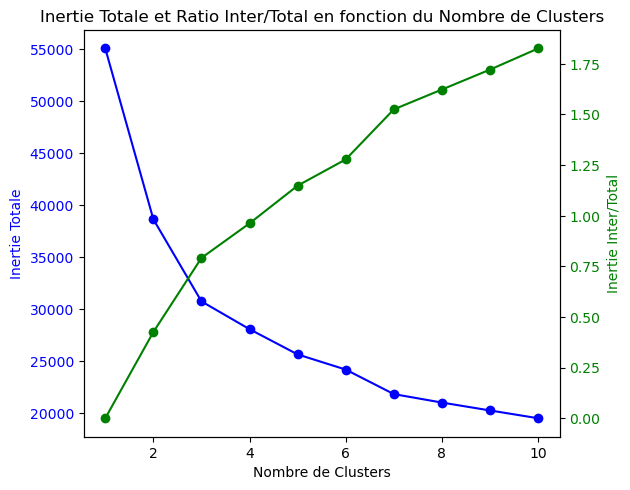

In [6]:
# Calcul de l'inertie pour différents nombres de clusters
inter_inertia_values = []
total_inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data)
    
    # Inertie totale
    total_inertia = kmeans.inertia_
    total_inertia_values.append(total_inertia)
    
    # Calcul de l'inertie inter
    centroids = kmeans.cluster_centers_
    labels = kmeans.labels_
    # Centroid global (moyenne de tous les points)
    global_centroid = np.mean(data, axis=0)
    
    # Calcul de l'inertie inter
    inter_inertia = 0
    for i in range(k):
        # Points dans le cluster i
        cluster_points = data[labels == i]
        # Nombre de points dans le cluster i
        n_i = cluster_points.shape[0]
        # Distance entre le centroid du cluster et le centroid global
        inter_inertia += n_i * np.linalg.norm(centroids[i] - global_centroid)**2
    
    inter_inertia_values.append(inter_inertia)

# Calcul du ratio Inertie Inter / Inertie Totale
inter_total_ratio = [inter / total if total != 0 else 0 for inter, total in zip(inter_inertia_values, total_inertia_values)]

# Tracer l'inertie totale et le ratio Inter/Total
fig, ax1 = plt.subplots()

ax1.plot(K_range, total_inertia_values, marker='o', color='blue', label='Inertie Totale')
ax1.set_xlabel('Nombre de Clusters')
ax1.set_ylabel('Inertie Totale', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(K_range, inter_total_ratio, marker='o', color='green', label='Inertie Inter/Total')
ax2.set_ylabel('Inertie Inter/Total', color='green')
ax2.tick_params(axis='y', labelcolor='green')

fig.tight_layout()
plt.title('Inertie Totale et Ratio Inter/Total en fonction du Nombre de Clusters')
plt.show()


In [32]:
# Nombre de clusters (K) à définir, ajustez selon votre problème
k = 4  # Exemple pour 4 clusters

# Appliquer KMeans
kmeans = KMeans(n_clusters=4, random_state=42)  # random_state pour la reproductibilité
kmeans.fit(data)  # Entrée des données normalisées

# Obtenir les labels des clusters (indices de chaque cluster pour chaque point)
labels = kmeans.labels_

# Ajouter les labels au dataframe pour faciliter l'analyse
data.loc[:, 'Cluster'] = labels

Cluster
0    148590
1    148482
2    109245
3     47635
Name: count, dtype: int64


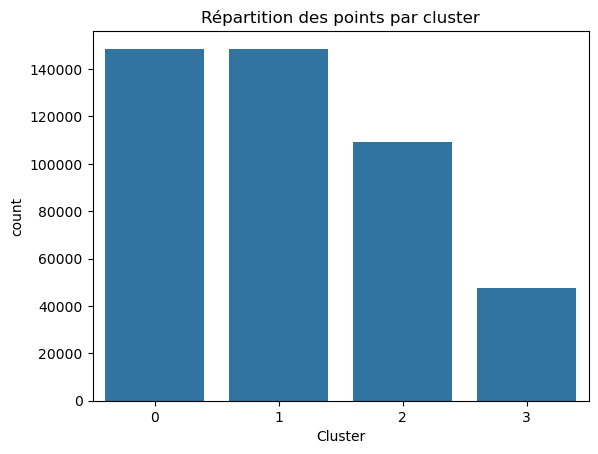

In [33]:
# Comptage du nombre de points dans chaque cluster
cluster_counts = data['Cluster'].value_counts()
print(cluster_counts)

# Visualisation de la répartition des clusters
sns.countplot(x='Cluster', data=data)
plt.title("Répartition des points par cluster")
plt.show()

In [34]:
# Affichage des centroids des clusters
centroids = kmeans.cluster_centers_

# Exclure la colonne 'Cluster' en utilisant la méthode drop
centroid_df = pd.DataFrame(centroids, columns=data.columns)

print(centroid_df)

        M_H    VMICRO    VMACRO      C_FE     CI_FE      N_FE      O_FE  \
0  0.776657  0.210470  0.264296  0.609729  0.561586  0.356066  0.461785   
1  0.602678  0.264077  0.356430  0.627265  0.605350  0.329188  0.569572   
2  0.782304  0.095125  0.000002  0.607371  0.583713  0.293118  0.462745   
3  0.669104  0.076620  0.000005  0.645413  0.635167  0.245997  0.533356   

      NA_FE     MG_FE     AL_FE     SI_FE      S_FE      K_FE     CA_FE  \
0  0.584830  0.489050  0.479041  0.424448  0.466498  0.628710  0.473328   
1  0.572060  0.596437  0.524868  0.498918  0.569163  0.662803  0.529244   
2  0.565277  0.462925  0.508577  0.442818  0.430726  0.619207  0.468795   
3  0.544119  0.558263  0.536078  0.476794  0.507093  0.651485  0.513906   

      TI_FE      V_FE     CR_FE     MN_FE     NI_FE      FE_H       Cluster  
0  0.510607  0.499732  0.647221  0.580045  0.622465  0.779608  3.836931e-13  
1  0.519118  0.512335  0.635417  0.548520  0.628673  0.601507  2.000000e+00  
2  0.420371  0

In [10]:
#VMicro/VMacro très importants, 
#3ème cluster souvent différent des 1,2,4 qui sont proches

In [35]:
# Ajouter la colonne 'Cluster' à vos données
data['Cluster'] = kmeans.labels_

# Calculer l'écart-type de chaque colonne par cluster
cluster_dispersion = data.groupby('Cluster').std()  # Ecart-type pour chaque cluster
print(cluster_dispersion)

              M_H    VMICRO    VMACRO      C_FE     CI_FE      N_FE      O_FE  \
Cluster                                                                         
0        0.061115  0.075258  0.045179  0.036811  0.040782  0.050114  0.035000   
1        0.093661  0.085079  0.085780  0.059771  0.061112  0.061165  0.072693   
2        0.053475  0.100261  0.000675  0.030045  0.030378  0.081365  0.058229   
3        0.053002  0.084127  0.001062  0.037550  0.040033  0.082008  0.077606   

            NA_FE     MG_FE     AL_FE     SI_FE      S_FE      K_FE     CA_FE  \
Cluster                                                                         
0        0.044140  0.036411  0.028248  0.022726  0.041360  0.031738  0.028975   
1        0.068103  0.075358  0.062305  0.054397  0.084527  0.036035  0.045377   
2        0.093042  0.039088  0.033901  0.029547  0.050095  0.030551  0.033055   
3        0.119712  0.074187  0.044240  0.045976  0.072469  0.038464  0.048288   

            TI_FE      V_F

d:\users\22403749t\AppData\Local\Temp\ipykernel_9052\2092512363.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Cluster'] = kmeans.labels_


In [36]:
# Calcul des statistiques descriptives par cluster
cluster_stats = data.groupby('Cluster').describe()
print(cluster_stats)

              M_H                                                              \
            count      mean       std       min       25%       50%       75%   
Cluster                                                                         
0        148590.0  0.776657  0.061115  0.378286  0.728886  0.770758  0.818901   
1        148482.0  0.602678  0.093661  0.000000  0.573450  0.623186  0.661289   
2        109245.0  0.782304  0.053475  0.364339  0.745507  0.781199  0.817126   
3         47635.0  0.669104  0.053002  0.383499  0.634934  0.672160  0.705422   

                     VMICRO                                                    \
              max     count      mean       std       min       25%       50%   
Cluster                                                                         
0        1.000000  148590.0  0.210470  0.075258  0.000000  0.179765  0.216948   
1        0.810257  148482.0  0.264077  0.085079  0.000000  0.222835  0.266713   
2        0.967305  109245.0

In [37]:
# Calcul du score de silhouette
silhouette_avg = silhouette_score(data, kmeans.labels_)
print(f"Score de silhouette : {silhouette_avg}")

Score de silhouette : 0.7138555766251394


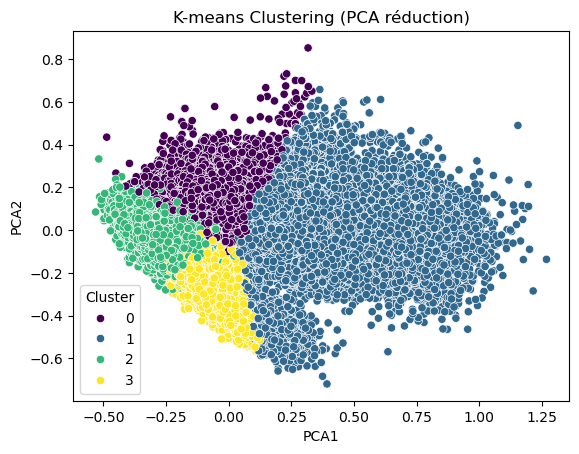

In [38]:
# Réduction de dimensionnalité à 2D avec PCA pour la visualisation
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data.drop('Cluster', axis=1))

# Créer un DataFrame avec les nouvelles dimensions et les labels
data_pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
data_pca_df['Cluster'] = data['Cluster']

# Visualisation
sns.scatterplot(x=data_pca_df['PCA1'], y=data_pca_df['PCA2'], hue=data_pca_df['Cluster'], palette='viridis')
plt.title('K-means Clustering (PCA réduction)')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

In [45]:
'''import plotly.express as px
from sklearn.decomposition import PCA

# Réduction de dimensionnalité à 3D avec PCA
pca = PCA(n_components=3)
data_pca = pca.fit_transform(data.drop('Cluster', axis=1))

# Créer un DataFrame avec les nouvelles dimensions et les labels
data_pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2', 'PCA3'])
data_pca_df['Cluster'] = data['Cluster']

# Créer un graphique 3D interactif avec Plotly
fig = px.scatter_3d(data_pca_df, x='PCA1', y='PCA2', z='PCA3', color='Cluster', title="3D PCA plot")

# Afficher le graphique interactif
fig.show()

SyntaxError: incomplete input (3637743097.py, line 1)

In [ ]:
# DBSCAN

In [15]:
echantillon = data.sample(frac=0.25, random_state=42)  # 10% des données

In [24]:
# Appliquer DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=40)  # paramètres Epsilon : distance max entre 2 points, min_sample : nombre de points min pour former une région dense
labels = dbscan.fit_predict(echantillon)

In [26]:
# Ajouter les labels au dataframe
echantillon['Cluster'] = labels

# Afficher les clusters trouvés
print(echantillon['Cluster'].value_counts())

Cluster
 2    38737
 1    28177
 0    27630
 3    16767
-1     1458
 4      719
Name: count, dtype: int64


In [ ]:
Prendre des medoids le long des clusters (comme les centroids de kmeans)
forme dues clusters 

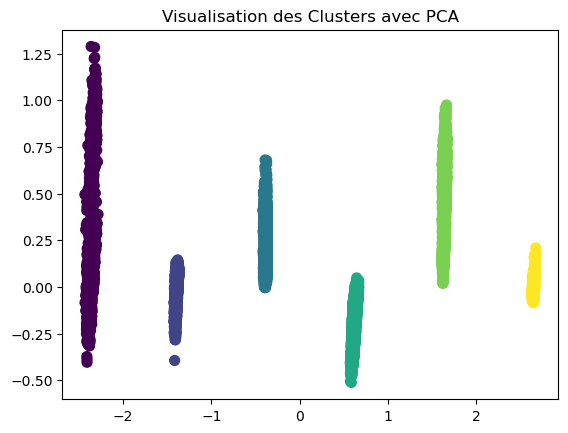

In [ ]:
# Pourquoi c'est moche comme ca
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(echantillon)
# Visualisation des clusters
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='viridis', s=50)
plt.title('Visualisation des Clusters avec PCA')
plt.show()

In [1]:
#Skope-rules

In [6]:
import collections.abc
import six
import sklearn
collections.Iterable = collections.abc.Iterable
sklearn.externals.six = six
from skrules import SkopeRules

In [43]:
echantillon_all_data = all_data.sample(frac=0.1, random_state=42)  # échantillonage des données

In [44]:
X = echantillon_all_data[variable_utiles].values  # Extraction des variables utiles

y = echantillon_all_data['class_spectral']  # Supposons que votre dataset a une colonne cible "target"

clf = SkopeRules(max_depth_duplication=2,
                n_estimators=30,
                precision_min=0.3,
                recall_min=0.1,
                feature_names=variable_utiles)

# On entraîne un modèle pour chaque classe présente dans y
for idx in sorted(set(y)):
    clf.fit(X, y == idx)
    rules = clf.rules_[0:3]
    print(f"Rules for class {idx}")
    for rule in rules:
        print(rule)
    print('\n' + '=' * 20 + '\n')

Rules for class F
('VMICRO > 0.14433756470680237 and SI_FE > 0.4260995239019394 and MG_FE <= 0.433620348572731', (0.7172874880611271, 0.3783375314861461, 1))
('VMACRO <= 0.10512158274650574 and N_FE > 0.45656056702136993 and MG_FE > 0.4333660900592804', (0.8024316109422492, 0.13253012048192772, 1))
('N_FE <= 0.13524413853883743 and MG_FE > 0.4263208508491516', (0.43915343915343913, 0.12691131498470948, 1))


Rules for class G
('VMICRO <= 0.2315821498632431 and TI_FE <= 0.4683511257171631 and VMACRO <= 0.09609769284725189', (0.7478820738732633, 0.6040782811003148, 1))
('VMICRO <= 0.21649127453565598 and VMACRO <= 0.09758671373128891 and AL_FE <= 0.5091081261634827', (0.45528290407625227, 0.3074921243665251, 1))
('TI_FE > 0.45477135479450226 and VMACRO <= 0.09609769284725189 and AL_FE > 0.5226800441741943', (0.5786886784520007, 0.24368790573075683, 2))


Rules for class K
('NI_FE > 0.4904983788728714 and VMACRO > 0.09541864693164825 and N_FE <= 0.9276206493377686', (0.996250646440269, 0.

In [ ]:
'''skope rules 

Rules for class F
('VMICRO > 0.14433756470680237 and SI_FE > 0.4260995239019394 and MG_FE <= 0.433620348572731', (0.7172874880611271, 0.3783375314861461, 1))

====================

Rules for class G
('VMICRO <= 0.2315821498632431 and TI_FE <= 0.4683511257171631 and VMACRO <= 0.09609769284725189', (0.7478820738732633, 0.6040782811003148, 1))

====================

Rules for class K
('NI_FE > 0.4904983788728714 and VMACRO > 0.09541864693164825 and N_FE <= 0.9276206493377686', (0.996250646440269, 0.8566293633736011, 1))
('VMICRO <= 0.8793551623821259 and NI_FE > 0.49349842965602875 and VMACRO > 0.09541864693164825', (0.9960303762512944, 0.8558505116417026, 1))


'Sachant que 75% des données sont classe K
'20% sont classe G
'5% sont classe F

class_spectral
K    338381
G     91162
F     24409
Name: count, dtype: int64


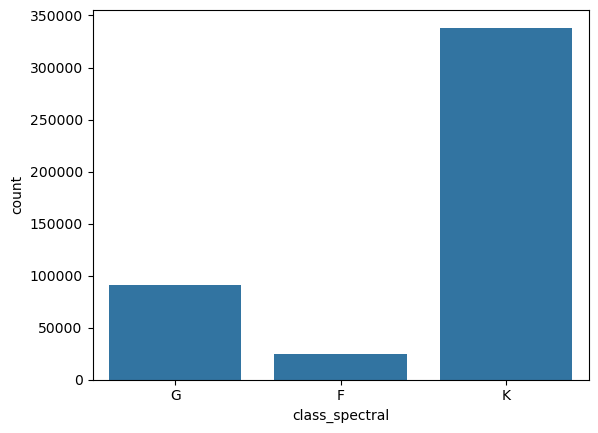

In [25]:
sns.countplot(x='class_spectral',data=all_data)
print(all_data['class_spectral'].value_counts())

In [7]:
# Tester kmedoids ? Peut être long

In [9]:
import hdbscan

In [10]:
from packaging import version
arg = "force_all_finite" if version.parse(sklearn.__version__) < version.parse("1.6") else "ensure_all_finite"

NameError: name 'sklearn' is not defined

In [11]:
# Initialisation du modèle HDBSCAN
hdbscan_cluster = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)

# Ajustement du modèle et prédiction des clusters
labels = hdbscan_cluster.fit_predict(echantillon)

# Affichage des résultats
np.unique(labels, return_counts=True)

c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\axioz\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8]),
 array([ 5509, 14921,    14,    12,    11,    19,    17, 24846,    13,
           33]))

In [12]:
hdbscan_cluster.probabilities_

array([1.        , 0.78404642, 1.        , ..., 1.        , 1.        ,
       1.        ])